Keys in the .mat file:
- GT: <class 'h5py._hl.dataset.Dataset'>, Shape: (808, 1098)
- HSI: <class 'h5py._hl.dataset.Dataset'>, Shape: (270, 808, 1098)
Keys in the .mat file:
- GT: <class 'h5py._hl.dataset.Dataset'>, Shape: (808, 1098)
- HSI: <class 'h5py._hl.dataset.Dataset'>, Shape: (270, 808, 1098)


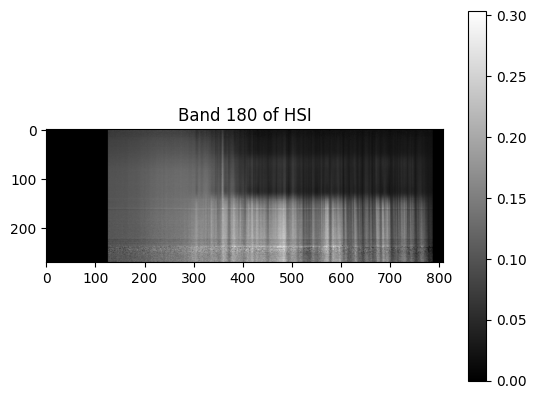

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Load the .mat file using h5py
def load_hdf5_mat_file(file_path):
    try:
        data = h5py.File(file_path, 'r')
        return data
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None

# Explore the contents of the .mat file
def explore_hdf5_data(data):
    if data:
        print("Keys in the .mat file:")
        def print_keys(group, prefix=""):
            for key in group:
                full_key = f"{prefix}/{key}" if prefix else key
                if isinstance(group[key], h5py.Group):
                    print_keys(group[key], full_key)
                else:
                    print(f"- {full_key}: {type(group[key])}, Shape: {group[key].shape}")
        
        print_keys(data)

# Visualize a hyperspectral image band
def visualize_hdf5_band(data, key, band_index):
    try:
        dataset = data[key]
        if len(dataset.shape) == 3:  # Hyperspectral data should have 3 dimensions (x, y, bands)
            band_data = dataset[:, :, band_index]
            plt.imshow(band_data, cmap='gray')
            plt.title(f"Band {band_index} of {key}")
            plt.colorbar()
            plt.show()
        else:
            print(f"The selected key '{key}' does not contain 3D hyperspectral data.")
    except Exception as e:
        print(f"Error visualizing band: {e}")

# Load the .mat file and list all keys
def explore_hdf5_keys(file_path):
    try:
        with h5py.File(file_path, 'r') as f:
            print("Keys in the .mat file:")
            def print_keys(group, prefix=""):
                for key in group:
                    full_key = f"{prefix}/{key}" if prefix else key
                    if isinstance(group[key], h5py.Group):
                        print_keys(group[key], full_key)
                    else:
                        print(f"- {full_key}: {type(group[key])}, Shape: {group[key].shape}")
            
            print_keys(f)
    except Exception as e:
        print(f"Error exploring keys: {e}")


# Jupyter Notebook Workflow
# Path to your .mat file
file_path = r"C:\Users\ChloeAtherton\Capstone\data\NC13.mat"

# Load the file
mat_data = load_hdf5_mat_file(file_path)

if mat_data:
    # Explore the data structure
    explore_hdf5_keys(file_path)
    explore_hdf5_data(mat_data)

    # Replace 'your_key_here' with the correct key and specify the band index to visualize
    key  = "HSI"  # Replace with the actual key containing hyperspectral data
    band_index = 180  # Replace with the desired band index

    with h5py.File(file_path, 'r') as f:
        visualize_hdf5_band(f, key, band_index)